In [1]:
# NUMERICAL & DATA MANIPULATION

import pandas as pd
import numpy as np

# DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

### **Data import**

In [2]:
# CREATE A DATA FRAME FROM EACH CSV FILE IN THE DATA FOLDER

customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')


#### **1. EDA**

The content of each single dataset is explored to ensure consistency and spot possible issues.

##### **Customers dataset**

All data formats are appropriate and no null values are present in the data frame

In [3]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

customers.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [4]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [6]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The customer dataframe has {customers.duplicated().sum()} duplicated entries.')

The customer dataframe has 0 duplicated entries.


In [7]:
# MAKE SURE CUSTOMER_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert customers['customer_id'].is_unique

The number of unique values in the customer_id and customer_unique_id do not match.
This discrepancy is expected, as a new customer_id is assigned to each individual purchase made by the same unique customer (customer_unique_id), resulting in duplicated values in the customer_unique_id column.
That mean customer_id is the primary key of the data frame, which also appears as a foreign key in other frames. Using customer_id ensures that all orders can be merged correctly and consistently mapped across datasets.

In [8]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

customers.nunique(dropna=False)

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [9]:
# DISPLAY THE NUMBER OF UNIQUE VALUES (FALSE) AND DUPLICATED VALUES (TRUE) IN THE CUSTOMER_UNIQUE_ID

customers['customer_unique_id'].duplicated().value_counts()

customer_unique_id
False    96096
True      3345
Name: count, dtype: int64

##### **Order items dataset**

There are no null values present, and most data types are correctly assigned. However, the shipping_limit_date column needs to be converted to a datetime format, as it is currently stored as an object.

In [10]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

order_items.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [11]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [12]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

**Adjusting wrond data types**

In [13]:
# TRANSFORM THE SHIPPING_LIMIT_DATE DATA TYPE FROM OBJECT TO DATE

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors= 'coerce')

In [14]:
# DISPLAY THE NEW DATA TYPE FOR SHIPPING_LIMIT_DATE

order_items['shipping_limit_date'].dtype

dtype('<M8[ns]')

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [15]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The order items dataframe has {order_items.duplicated().sum()} duplicated entries.')

The order items dataframe has 0 duplicated entries.


In [16]:
# MAKE SURE ORDER_ID AND ORDER_ITEMS ARE UNIQUE, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert not order_items.duplicated(['order_id','order_item_id']).any()

The number of unique values in the order_id column (98,666) is lower than the total number of records in the orders DataFrame (99,491). This discrepancy is likely due to orders that were canceled, recently placed, or are still in an initial status but went lost

This issue will be addressed once the Data frames are merged and the order lifecycle is analyzed more comprehensively.

In [17]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

order_items.nunique(dropna= False)

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

##### **Orders dataset**

The orders dataset requires special attention in the following areas:

* **Date and time fields** are incorrectly formatted as objects and need to be converted to proper date or datetime formats.
* **Check the order status** to be sure all orders have been delivered as the data is not recent
* **Check the data distribution** based on the year and month
* **Missing (null) values** are present; a more in-depth exploratory analysis will be conducted to determine the appropriate handling strategy for these records.

In [18]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [19]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [20]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The orders dataframe has {orders.duplicated().sum()} duplicated entries.')

The orders dataframe has 0 duplicated entries.


In [21]:
# MAKE SURE ORDER_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert orders['order_id'].is_unique

**Handling wrong data types**

In [22]:
# LIST OF COLUMNS THAT SHOULD BE DATETIME BUT CURRENTLY HAVE THE WRONG DATA TYPE.

dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


# APPLY CORRECT DATA TYPE TO THE LISTED COLUMNS

orders[dates] = orders[dates].apply(pd.to_datetime, errors= 'coerce')


In [23]:
# CHECK THE NEW DATA TYPES HAVE BEEN CONVERTED PROPERLY

orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

**Is the data consistent throughout the time?**

Data collection issues were identified in 2017, along with a reporting lag starting in September 2018. To maintain the integrity of the study and prevent these inconsistencies from distorting the results, these periods have been excluded from the analysis.

In [24]:
# ADD A YEAR, MONTH, AND ISOWEEK COLUMN FOR EACH ORDER

orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month_name()
orders['iso_week'] = orders['order_purchase_timestamp'].dt.isocalendar()['week']

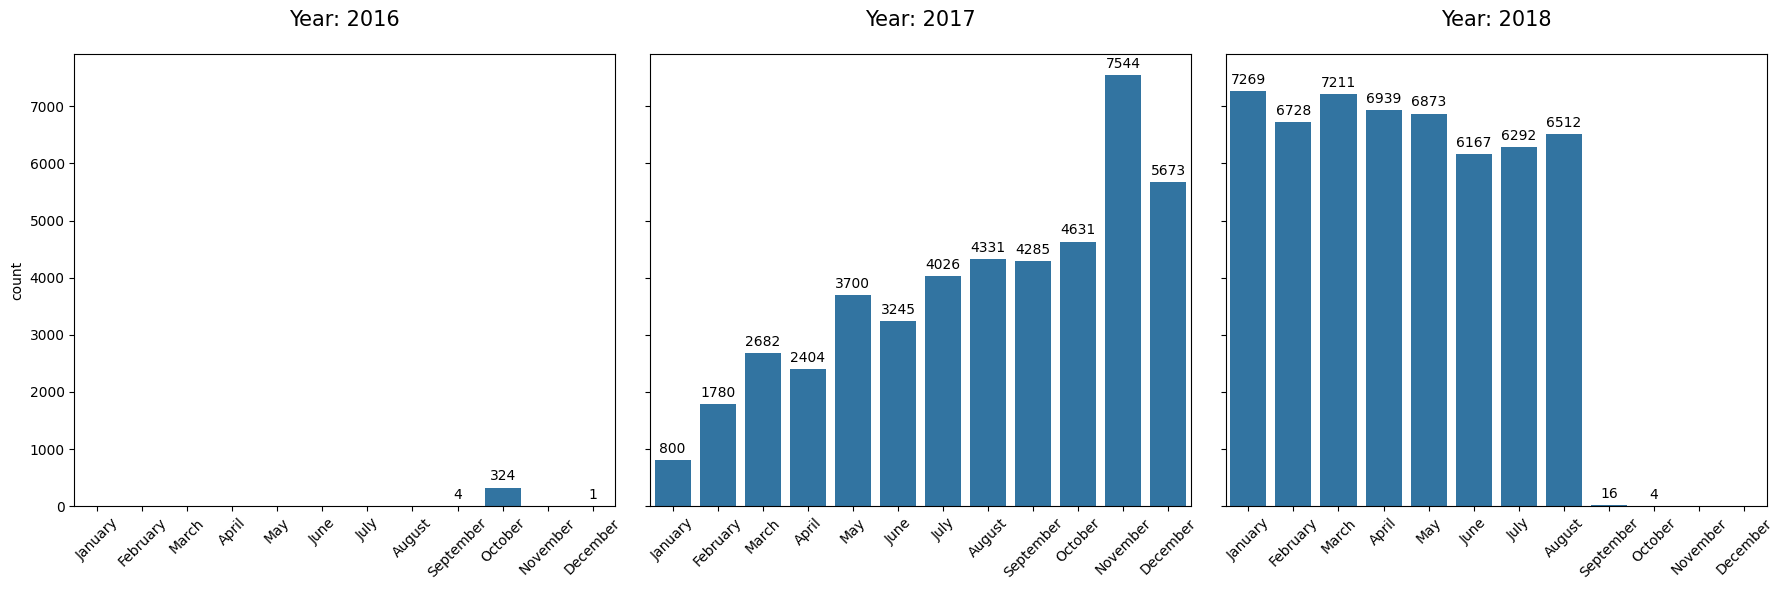

In [25]:
# GENERATE A BAR CHART WITH ALL ORDERS PER YEAR AND MONTH

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

years = sorted(orders['year'].unique())
rows_chart_1 = int(np.ceil(len(years) / 3))


fig, axes = plt.subplots(rows_chart_1, 3, figsize=(18, 6), sharey=True)
axes = axes.flatten()

for i, time in enumerate(years):
    data_year = orders[orders['year'] == time]
    
    
    plot = sns.countplot(data=data_year, x='month', ax=axes[i], order=month_order)
    

    axes[i].bar_label(axes[i].containers[0], padding=3, fontsize=10)

    
    axes[i].set_title(f'Year: {time}', fontsize=15, pad=20)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [26]:
# FILTER OUT ORDERS IN PLACED IN 2016 AND FROM AUGUST 2018 ONWARDS

orders = orders[(orders['order_purchase_timestamp'] >= '2017-01-01') & (orders['order_purchase_timestamp'] < '2018-09-01')]


In [27]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,iso_week
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,October,40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,July,30
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,August,32


In [28]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99092 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status                   99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   order_approved_at              98957 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 6   order_delivered_customer_date  96204 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 8   year                           99092 non-null  int32         
 9   month                          99092 non-null  object        
 10  iso_week                       99092 non-null  UInt32        
dtypes: UInt32(1), dateti

**Have all orders been delivered?**

The orders were dispatched between 2016 and 2018. However, a significant number of them were not delivered and still appeared under statuses such as shipped, unavailable, invoiced, processing, created, or approved status.

Since it is not possible to determine what ultimately happened to these orders, any order that was neither delivered nor canceled is considered lost.

In [29]:
# SHOW THE NUMBER OF ORDERS BY THE ORDER STATUS

orders['order_status'].value_counts(dropna= False)

order_status
delivered      96211
shipped         1097
unavailable      602
canceled         580
processing       299
invoiced         296
created            5
approved           2
Name: count, dtype: int64

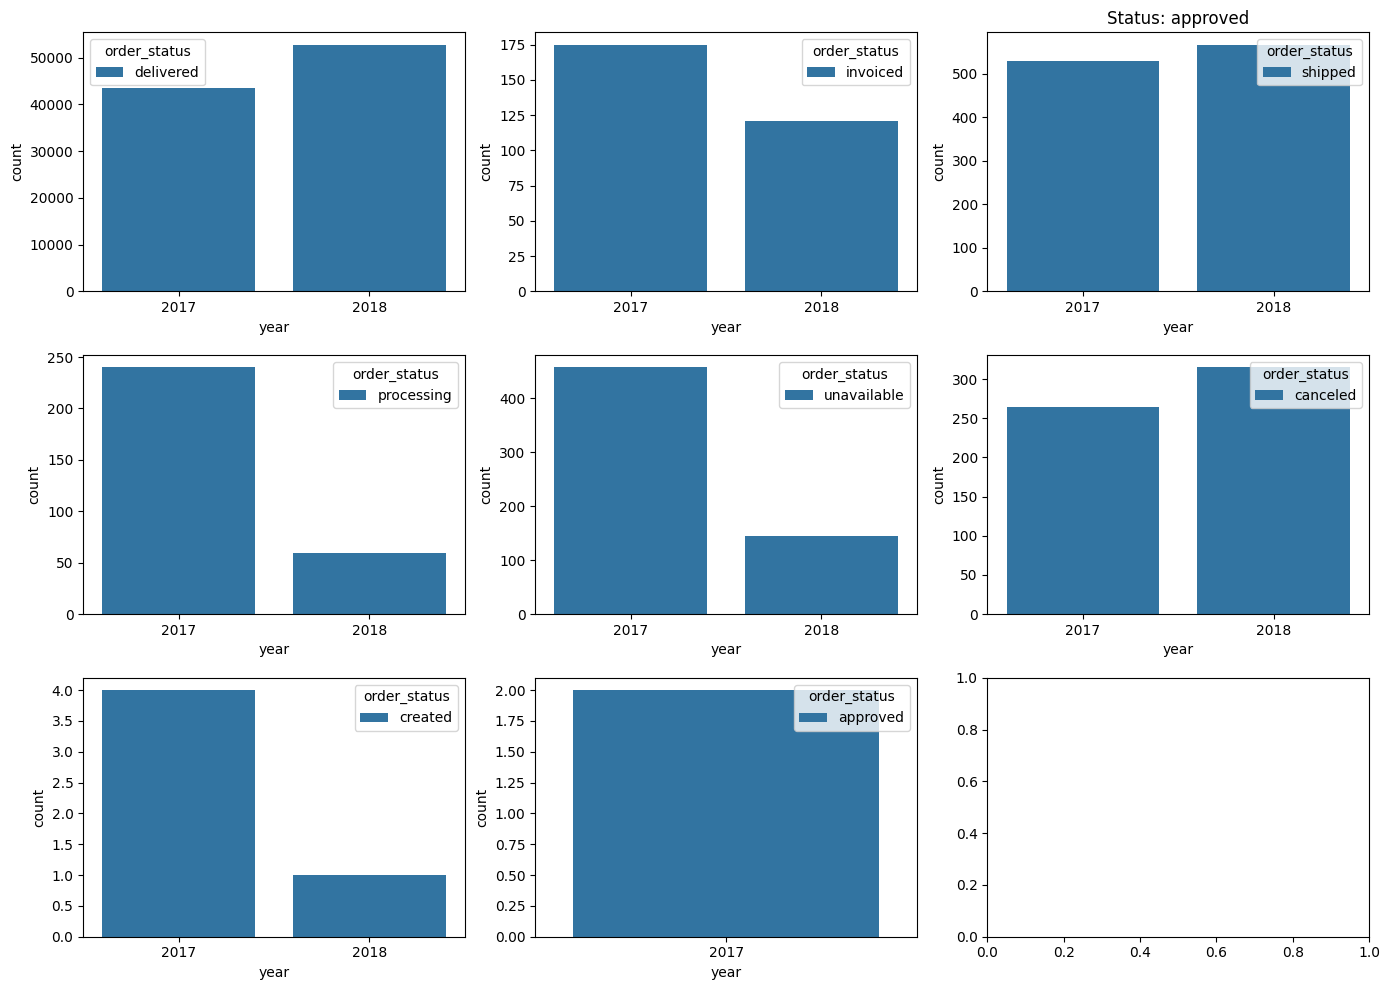

In [30]:
# EXTRACT UNIQUE VALUES CONTAINED IN THE ORDER_STATUS COLUMN
unique_statuses = orders['order_status'].unique()

# DEFINE THE GRID FOR THE CHARTS
rows_chart_2 = int(np.ceil( len(unique_statuses) / 3))
fig, axes = plt.subplots(rows_chart_2, 3, figsize=(14, 10))

# CONVERT A 3x3 MATRIX INTO A FLAT LIST OF 9 ELEMENTS
axes = axes.flatten()

# RUN A LOOP TO GENERATE ALL CHARTS
for ii, status in enumerate(unique_statuses):

    filter_data = orders[orders['order_status'] == status]
    sns.countplot(data=filter_data, x='year', hue='order_status', ax=axes[ii])
    axes[i].set_title(f"Status: {status}")
    
plt.tight_layout()

    

In [31]:
# CATEGORIZE THE ORDER_STATUS BETWEEN DELIVERED, CANCELED, OR LOST

orders['order_status_real'] = orders['order_status'].apply(lambda x: 'delivered' if x == 'delivered'
                                                        else 'canceled' if x == 'canceled'
                                                        else 'lost' )

In [32]:
# SHOW THE NUMBER OF ORDERS BY THE ORDER STATUS

orders['order_status_real'].value_counts()

order_status_real
delivered    96211
lost          2301
canceled       580
Name: count, dtype: int64

**Handling null values**

Intuitively, some of the missing values are expected as most of them belong to orders that were canceled or went missing, with just 23 entries missing some values
Let’s investigate this in more detail.

In [33]:
# DISPLAY NUMBER OF NULL VALUES PER COLUMN

orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 135
order_delivered_carrier_date     1716
order_delivered_customer_date    2888
order_estimated_delivery_date       0
year                                0
month                               0
iso_week                            0
order_status_real                   0
dtype: int64

In [34]:
# GENERATE A DATA FRAME WITH ALL ENTRIES CONTAINING AT LEAST A NULL VALUE

orders_nulls = orders.loc[orders.isnull().any(axis=1)].copy()


# DISPLAY TOP 3 ROWS OF THE NEWLY CREATED MISSING_DATA FRAME

orders_nulls.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,iso_week,order_status_real
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,2017,April,15,lost
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28,2018,June,23,lost
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,2018,August,31,lost


In [35]:
# DISTRIBUTION OF NULLS BY ORDER STATUS

orders_nulls['order_status_real'].value_counts()

order_status_real
lost         2301
canceled      579
delivered      23
Name: count, dtype: int64

The missing data will be retained, as it does not affect the analysis and the key KPIs remain intact.

In [36]:
orders_nulls[orders_nulls['order_status_real'] == 'delivered']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,iso_week,order_status_real
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,2017,November,48,delivered
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17,2017,February,7,delivered
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21,2017,February,7,delivered
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17,2017,February,7,delivered
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,2018,June,25,delivered
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31,2017,February,7,delivered
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20,2017,February,7,delivered
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01,2017,January,3,delivered
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27,2017,February,7,delivered
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22,2017,February,7,delivered


In [37]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

orders.nunique(dropna= False)

order_id                         99092
customer_id                      99092
order_status                         8
order_purchase_timestamp         98526
order_approved_at                90411
order_delivered_carrier_date     80749
order_delivered_customer_date    95395
order_estimated_delivery_date      420
year                                 2
month                               12
iso_week                            52
order_status_real                    3
dtype: int64

##### **Products dataset**

All formats make sense. However, there is an important number of null values that need further review and handling.

In [38]:
# DISPLAY TOP TWO ROWS IN THE DATAFRAME

products.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [39]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Handling nulls values**

Most of the missing values affect production related KPIs such as category name, name length, product description length, and number of pictures. This may indicate that these products are new additions to the catalog and had not yet been processed at the time of data extraction.

In [40]:
# CHECK NUMBER OF NULL VALUES PER COLUMN

products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

The products affected by nulls have all driven sales and therefore, due to their relevance they will be kept as they are to avoid distortions, except for the category_column_name, which is going to be treated as 'unkown'.

In [41]:
# CREATE A DATA FRAME WITH ALL NULLS

products_nulls = products.loc[products.isnull().any(axis=1)]

# CREATE A DATA FRAME WITH REVENUEW GENERATED BY EACH PRODUCT

products_revenue = order_items[['product_id', 'price']].groupby(by= 'product_id', as_index= False).sum()

In [42]:
# JOIN THE PRODUCTS WITH NULLS AND THEIR REVENUE

products_null_revenue = pd.merge(left= products_nulls['product_id'] ,right= products_revenue, how= 'inner', on= 'product_id')

In [43]:
# CHECK THE TOTAL REVENUE GENERATED BY THE PRODUCTS AFFECTED BY NULLS

print(f'All products have generated sales for {products_null_revenue.price.sum()}')

# CHECK IF THERE ARE NULLS IN THE PRICE COLUMN

print(f'There are no missing values ({products_null_revenue.price.isnull().sum()} duplicates) indicating that every product has been sold at least once')

# DISPLAY THE TOP THREE ENTRIES STARTING BY THE LOWEST REVENUE

products_null_revenue.sort_values(by= 'price').head(3)


All products have generated sales for 181469.28
There are no missing values (0 duplicates) indicating that every product has been sold at least once


,product_id,price
103,dc9f66a56b89e4278d921898a861a29a,3.90
581,2cd7d0ade9eb52c856a16dce303397ad,4.85
324,28fff36d13d492328583ee2b1d72f78f,5.20


Filling the null values from the product_category_name with 'unknown'

In [44]:
# FILL NULLS VALUES FROM THE PRODUCT_CATEGORY_NAME WITH 'UNKNOWN'

products['product_category_name'] = products['product_category_name'].fillna('unknown')


In [45]:
# CHECK NUMBER OF NULLS PER COLUM

products.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

The data frame currently contains no duplicate records. However, as a best practice and to ensure robustness, an additional line of code will be included to prevent potential duplication if new data entries are introduced in the future.

In [46]:
# CHECK IF THE DATAFRAME CONTAINS DUPLICATED DATA.

print(f'The product dataframe has {products.duplicated().sum()} duplicated entries.')

The product dataframe has 0 duplicated entries.


In [47]:
# MAKE SURE PRODUCT_ID CONTAINS ONLY UNIQUE VALUES, OTHERWISE THE CODE WILL BREAK AND STOP HERE IF FUTURES ENTRIES INTRODUCE DUPLICATES 

assert products['product_id'].is_unique

In [48]:
# DISPLAY THE NUMBER OF UNIQUE VALUES PER COLUMN

products.nunique(dropna= False)

product_id                    32951
product_category_name            74
product_name_lenght              67
product_description_lenght     2961
product_photos_qty               20
product_weight_g               2205
product_length_cm               100
product_height_cm               103
product_width_cm                 96
dtype: int64

### **Defining final data frames for analysis**

First, the most relevant KPIs will be defined to allow them to be merged and to ensure the most meaningful data is obtained.

In [49]:
# GENERATE THE FINAL FRAMES THAT WILL BE MERGED

customers_final = customers.copy()

orders_final = orders[['order_id', 'customer_id', 'order_status_real', 'order_purchase_timestamp', 'year', 'month', 'iso_week', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']].copy()

order_items_final = order_items[['order_id', 'product_id', 'seller_id', 'order_item_id', 'price', 'freight_value']].copy()

products_final = products[['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].copy()

### **1. Orders**

**a. Data frames adjustments**

Order_item_final will be merged into orders_final via a left join with orders_final as left table. Since order_item_final is not exhaustive (missing records due to lost or canceled parcels), the resulting null values will be preserved. This ensures data integrity by distinguishing between a zero value and a missing record, preventing skewed metrics in downstream analysis.


In [50]:
# FILTER OUT ORDERS THAT ARE NOT CONATINED IN ORDER_ITEMS_FINAL

missing_records = orders_final[~orders_final['order_id'].isin(order_items_final['order_id'])]
count_missing_records = missing_records['order_id'].count()

print(f'the orders_final data frame contains {count_missing_records} more than the order_items_final frame distributed as follows:')

missing_records['order_status_real'].value_counts()


the orders_final data frame contains 739 more than the order_items_final frame distributed as follows:


order_status_real
lost        607
canceled    132
Name: count, dtype: int64

Defining Data frames

In [51]:
# DEFINE AN AGGREGATED FRAME WITH THE RELEVENAT COLUMNS FROM THE ORDER_ITEMS DATA FRAME

agg_items = order_items_final.groupby(by= 'order_id', as_index= False).agg(
                                                                        number_items = ('product_id', 'count'),
                                                                        gmv_order = ('price', 'sum'),
                                                                        order_freight = ('freight_value', 'sum'))

# CREATE A COPY OF THE ORDERS_FINAL DATA FRAME TO AVOID CONTAMINATION WHEN RUNNING THE MERGING LOOP

orders_final_copy = orders_final.copy()

**b. Mergin the frames**

In [52]:
# LIST THE DATA FRAMES AND JOIN KEYS USE TO MERGE

orders_mergin_parameters = [(customers_final, 'customer_id'), (agg_items, 'order_id')]

# RUN A LOOP TO MERGE ALL DATA FRAMES

for frame, order_join_key in orders_mergin_parameters:
    
    df_orders = pd.merge(left= orders_final_copy, right= frame, how= 'left', on= order_join_key)
    orders_final_copy = df_orders
    
# DISPLAY THE TOP 3 ROWS OF THE NEWLY MERGED DATA FRAME

df_orders.head(3)

,order_id,customer_id,order_status_real,order_purchase_timestamp,year,month,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,number_items,gmv_order,order_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017,October,40,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018,July,30,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018,August,32,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22


In [53]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99092 entries, 0 to 99091
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status_real              99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   year                           99092 non-null  int32         
 5   month                          99092 non-null  object        
 6   iso_week                       99092 non-null  UInt32        
 7   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 8   order_delivered_customer_date  96204 non-null  datetime64[ns]
 9   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 10  customer_unique_id             99092 non-null  object        
 11  customer_zip_co

In [54]:
# ASSIGN INTEGER AS DATA TYPE FOR THE COLUMN NUMBER_ITEMS

df_orders['number_items'] = df_orders['number_items'].convert_dtypes('Int')

# DISPLAY NEW DATA TYPE FOR COLUMN NUMBER_ITEMS

df_orders['number_items'].dtype

Int64Dtype()

creating a file specifically for a Tableau side project

In [55]:
# Create a csv file 
df_orders.to_csv('cleaned_data/orders.csv')

**c. Feature engeeniring**

In [56]:
# ADD A FLAG IF ORDERS HAVE BEEN CANCELED, HAS FAILED DELIVERY; OR IT HAS BEN SUCCESFULLLY DELIVERED

df_orders['is_canceled'] = df_orders['order_status_real'] == 'canceled'
df_orders['is_lost'] = df_orders['order_status_real'] == 'lost'
df_orders['is_delivered'] = df_orders['order_status_real'] == 'delivered'


In [57]:

# ADD A COLUMN WITH THE REAL GMV DELIVERED 

df_orders['gmv_delivered'] = df_orders['is_delivered'] * df_orders['gmv_order']

# ADD COLUMNS WITH THE TOTAL GMV INVOLVED IN CANCELATIONS, LOST PARCELS, AND THE COMBINATION OF BOTH

df_orders['gmv_canceled'] = df_orders['is_canceled'] * df_orders['gmv_order']
df_orders['gmv_lost'] = df_orders['is_lost'] * df_orders['gmv_order']
df_orders['gmv_failed'] = df_orders['gmv_canceled'] + df_orders['gmv_lost']

In [58]:
# DISPLAY THE TOP 3 ROWS OF THE DATA FRAME

df_orders.head(3)

,order_id,customer_id,order_status_real,order_purchase_timestamp,year,month,iso_week,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,number_items,gmv_order,order_freight,is_canceled,is_lost,is_delivered,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017,October,40,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,...,1,29.99,8.72,False,False,True,29.99,0.0,0.0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018,July,30,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,...,1,118.70,22.76,False,False,True,118.70,0.0,0.0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018,August,32,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,...,1,159.90,19.22,False,False,True,159.90,0.0,0.0,0.0


**d. Final checks**

In [59]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_orders data frame contains {df_orders.shape[1]} columns, {df_orders.shape[0]} entries, and {df_orders.duplicated().sum()} duplicates.')

The df_orders data frame contains 24 columns, 99092 entries, and 0 duplicates.


In [60]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99092 entries, 0 to 99091
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99092 non-null  object        
 1   customer_id                    99092 non-null  object        
 2   order_status_real              99092 non-null  object        
 3   order_purchase_timestamp       99092 non-null  datetime64[ns]
 4   year                           99092 non-null  int32         
 5   month                          99092 non-null  object        
 6   iso_week                       99092 non-null  UInt32        
 7   order_delivered_carrier_date   97376 non-null  datetime64[ns]
 8   order_delivered_customer_date  96204 non-null  datetime64[ns]
 9   order_estimated_delivery_date  99092 non-null  datetime64[ns]
 10  customer_unique_id             99092 non-null  object        
 11  customer_zip_co

In [61]:
monthly = df_orders.groupby(['year', 'month']).agg(
    orders= ('order_id','count'),
    delivered_orders= ('is_delivered','sum'),
    cancellations= ('is_canceled','sum'),
    lost_parcels= ('is_lost','sum'),
    gmv_order= ('gmv_order','sum'),
    gmv_delivered= ('gmv_delivered','sum'),
    gmv_canceled = ('gmv_canceled', 'sum'),
    gmv_lost = ('gmv_lost', 'sum'),
    gmv_failed = ('gmv_failed','sum'),
).reset_index()

monthly['cancellation_rate'] = round(monthly['cancellations'] / monthly['orders'], 4).mul(100)
monthly['parcels_lost_rate'] = round(monthly['lost_parcels'] / monthly['orders'], 4).mul(100)
monthly['delivered_share'] = round(monthly['delivered_orders'] / monthly['orders'], 4).mul(100)

monthly.head(20)

,year,month,orders,delivered_orders,cancellations,lost_parcels,gmv_order,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed,cancellation_rate,parcels_lost_rate,delivered_share
0,2017,April,2404,2303,18,83,359927.23,340669.68,6084.25,13173.30,19257.55,0.75,3.45,95.80
1,2017,August,4331,4193,27,111,573971.68,554699.70,5725.89,13546.09,19271.98,0.62,2.56,96.81
2,2017,December,5673,5513,11,149,743914.17,726033.19,1730.38,16150.60,17880.98,0.19,2.63,97.18
3,2017,February,1780,1653,17,110,247303.02,234223.40,2343.67,10735.95,13079.62,0.96,6.18,92.87
4,2017,January,800,750,3,47,120312.87,111798.36,214.60,8299.91,8514.51,0.38,5.88,93.75
5,2017,July,4026,3872,28,126,498031.48,481604.52,5744.18,10682.78,16426.96,0.70,3.13,96.17
6,2017,June,3245,3135,16,94,433038.60,421923.37,3121.99,7993.24,11115.23,0.49,2.90,96.61
7,2017,March,2682,2546,33,103,374344.30,359198.85,6002.98,9142.47,15145.45,1.23,3.84,94.93
8,2017,May,3700,3546,29,125,506071.14,489338.25,2911.95,13820.94,16732.89,0.78,3.38,95.84
9,2017,November,7544,7289,37,218,1010271.37,987765.37,6409.23,16096.77,22506.00,0.49,2.89,96.62


### **2. Ordered items**

The most relevant KPIs are extracted from the order_items DataFrame and merged with KPIs from other sources, such as product category, order status, and order purchase timestamp.

**a. Data frames adjustments**

In [62]:
# GENERATE A COPY OR THE ORDER_ITEMS_FINAL TO GUARANTEED DATA CONSISTENCY

df_items = order_items_final.copy()

**b. Merging the frames**

In [63]:
# MERGE DATA FRAMES STEP BY STEP

df_items = df_items.merge(products_final, on='product_id', how='left', validate='many_to_one')
df_items = df_items.merge(orders_final, on='order_id', how='left', validate='many_to_one')

**c. Feature engeeniring**

In [64]:
# DROP COLUMN CUSTOMER_ID AND SELLER_ID AS THEY LACKS IN RELEVANCE FOR THIS DATA FRAME

df_items = df_items.drop(columns=['customer_id', 'seller_id'], errors= 'ignore')


# ADD COLUMNS A FLAG IF ORDERS HAVE BEEN CANCELED, HAS FAILED DELIVERY; OR IT HAS BEN SUCCESFULLLY DELIVERED

df_items['is_canceled'] = df_items['order_status_real'] == 'canceled'
df_items['is_lost'] = df_items['order_status_real'] == 'lost'
df_items['is_delivered'] = df_items['order_status_real'] == 'delivered'


In [65]:
# ADD 0 IN CASE OF NULL VALUES

df_items['price'] = df_items['price'].fillna(0)
df_items['item_freight'] = df_items['freight_value'].fillna(0)

# RENAME COLUMN PRICE

df_items.rename(columns={'price' : 'gmv_item'}, inplace= True)

# ADD A COLUMN WITH THE REAL GMV DELIVERED 

df_items['gmv_delivered'] = np.where(df_items['is_delivered'], df_items['gmv_item'], 0)

# ADD COLUMNS WITH THE TOTAL GMV INVOLVED IN CANCELATIONS, LOST PARCELS, AND THE COMBINATION OF BOTH

df_items['gmv_canceled'] = np.where(df_items['is_canceled'], df_items['gmv_item'], 0)
df_items['gmv_lost'] = np.where(df_items['is_lost'], df_items['gmv_item'], 0)
df_items['gmv_failed'] = df_items['gmv_canceled'] + df_items['gmv_lost']

In [66]:
# DISPLAY THE TOP 3 ROWS OF DATA FRAME

df_items.head(3)

,order_id,product_id,order_item_id,gmv_item,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,...,order_delivered_customer_date,order_estimated_delivery_date,is_canceled,is_lost,is_delivered,item_freight,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.9,13.29,cool_stuff,650.0,28.0,9.0,14.0,...,2017-09-20 23:43:48,2017-09-29,False,False,True,13.29,58.9,0.0,0.0,0.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,239.9,19.93,pet_shop,30000.0,50.0,30.0,40.0,...,2017-05-12 16:04:24,2017-05-15,False,False,True,19.93,239.9,0.0,0.0,0.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,199.0,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,...,2018-01-22 13:19:16,2018-02-05,False,False,True,17.87,199.0,0.0,0.0,0.0


**d. Final checks**

In [67]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_items data frame contains {df_items.shape[1]} columns, {df_items.shape[0]} entries, and {df_items.duplicated().sum()} duplicates.')


The df_items data frame contains 26 columns, 112650 entries, and 0 duplicates.


In [68]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   product_id                     112650 non-null  object        
 2   order_item_id                  112650 non-null  int64         
 3   gmv_item                       112650 non-null  float64       
 4   freight_value                  112650 non-null  float64       
 5   product_category_name          112650 non-null  object        
 6   product_weight_g               112632 non-null  float64       
 7   product_length_cm              112632 non-null  float64       
 8   product_height_cm              112632 non-null  float64       
 9   product_width_cm               112632 non-null  float64       
 10  order_status_real              112279 non-null  object        
 11  

### **3. Customers**

**a. Data frames adjustments**

In [69]:
# GENERATE A COPY OR THE CUSTOMERS_FINAL AND THE DF_ORDERS FRAMES TO GUARANTEED DATA CONSISTENCY

customers_final_copy = customers_final[['customer_unique_id',
                      'customer_zip_code_prefix',
                      'customer_city',
                      'customer_state']].drop_duplicates('customer_unique_id')

df_orders_copy = df_orders.copy()

In [70]:
# DEFINE AN AGGREGATED FRAME WITH THE RELEVENAT COLUMNS FROM THE ORDER_ITEMS DATA FRAME

agg_orders = df_orders_copy.groupby(by= 'customer_unique_id').agg(
                                                                        n_orders = ('order_id', 'count'),
                                                                        n_delivered = ('is_delivered', 'sum'),
                                                                        n_cancellations = ('is_canceled', 'sum'),
                                                                        n_lost_parcels = ('is_lost', 'sum'),
                                                                        gmv_order = ('gmv_order', 'sum'),
                                                                        gmv_delivered = ('gmv_delivered', 'sum'),
                                                                        gmv_canceled = ('gmv_canceled', 'sum'),
                                                                        gmv_lost = ('gmv_lost', 'sum'),
                                                                        gmv_failed = ('gmv_failed', 'sum'),
                                                                        order_freight = ('order_freight', 'sum'),
                                                                        avg_gmv_order = ('gmv_order', 'mean'),
                                                                        first_order_date = ('order_purchase_timestamp', 'min'),
                                                                        last_order_date = ('order_purchase_timestamp', 'max')
                                                                        )

**b. Merging the frames**

In [71]:
# MERGE AGG_ORDERS INTO CUSTOMERS_FINAL_COPY
    
df_customers = customers_final_copy.merge(right= agg_orders, how= 'left', on= 'customer_unique_id')

orders_final_copy = df_orders.copy()
    
# DISPLAY THE TOP 3 ROWS OF THE NEWLY MERGED DATA FRAME

df_customers.head(3)

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_orders,n_delivered,n_cancellations,n_lost_parcels,gmv_order,gmv_delivered,gmv_canceled,gmv_lost,gmv_failed,order_freight,avg_gmv_order,first_order_date,last_order_date
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1.0,1.0,0.0,0.0,124.99,124.99,0.0,0.0,0.0,21.88,124.99,2017-05-16 15:05:35,2017-05-16 15:05:35
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,1.0,1.0,0.0,0.0,289.00,289.00,0.0,0.0,0.0,46.48,289.00,2018-01-12 20:48:24,2018-01-12 20:48:24
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1.0,1.0,0.0,0.0,139.94,139.94,0.0,0.0,0.0,17.79,139.94,2018-05-19 16:07:45,2018-05-19 16:07:45


**c. Feature engeeniring**

In [72]:
# ADD THE COLUMNS CANCELLATION_RATE AND FAILURE_RATE

df_customers['cancellation_rate']  =  df_customers['n_cancellations'] / df_customers['n_orders'].replace(0, np.nan)
df_customers['failure_rate'] = df_customers['n_lost_parcels'] / df_customers['n_orders'].replace(0, np.nan)
df_customers['risk_score'] = df_customers['n_cancellations'] + df_customers['n_lost_parcels']


# CUSTOMER LIFECICLE
df_customers['lifetime_days'] = (df_customers['last_order_date'] - df_customers['first_order_date']).dt.days
df_customers['lifetime_days'] = df_customers['lifetime_days'].clip(lower=1)

df_customers['orders_per_day'] = df_customers['n_orders'] / df_customers['lifetime_days']
df_customers['gmv_delivered_per_day'] = df_customers['gmv_delivered'] / df_customers['lifetime_days']


In [73]:
df_customers['value_score'] = (
    df_customers['gmv_delivered'].rank(pct=True) * 0.7 +
    df_customers['n_orders'].rank(pct=True) * 0.3
)

In [74]:
v_cut = df_customers['value_score'].median()
r_cut = df_customers['risk_score'].median()

df_customers['value_band'] = np.where(df_customers['value_score'] >= v_cut, 'High Value', 'Low Value')
df_customers['risk_band']  = np.where(df_customers['risk_score']  >= r_cut, 'High Risk',  'Low Risk')

df_customers['segment'] = df_customers['value_band'] + " / " + df_customers['risk_band']
df_customers['segment'].value_counts()


segment
High Value / High Risk    47975
Low Value / High Risk     47799
Low Value / Low Risk        322
Name: count, dtype: int64

In [75]:
# DISPLAY THE TOP 3 ROWS OF DATA FRAME

df_customers.head(3)

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_orders,n_delivered,n_cancellations,n_lost_parcels,gmv_order,gmv_delivered,...,cancellation_rate,failure_rate,risk_score,lifetime_days,orders_per_day,gmv_delivered_per_day,value_score,value_band,risk_band,segment
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1.0,1.0,0.0,0.0,124.99,124.99,...,0.0,0.0,0.0,1.0,1.0,124.99,0.614765,High Value,High Risk,High Value / High Risk
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,1.0,1.0,0.0,0.0,289.00,289.00,...,0.0,0.0,0.0,1.0,1.0,289.00,0.779317,High Value,High Risk,High Value / High Risk
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1.0,1.0,0.0,0.0,139.94,139.94,...,0.0,0.0,0.0,1.0,1.0,139.94,0.647590,High Value,High Risk,High Value / High Risk


**d. Final checks**

In [76]:
# PROVIDE INFORMATION ABOUT THE NUMBER OF COLUMNS AND ROWS IN THE DATA FRAME

print(f'The df_customers data frame contains {df_customers.shape[1]} columns, {df_customers.shape[0]} entries, '
      f'which is equal to the number of rows of unique customers {customers_final_copy.customer_unique_id.nunique()} '
      f'in the customers_final frame and {df_customers.duplicated().sum()} duplicates.')



The df_customers data frame contains 27 columns, 96096 entries, which is equal to the number of rows of unique customers 96096 in the customers_final frame and 0 duplicates.


In [77]:
# INSPECT DATAFRAME MEDTADATA INCLUDING ENTRIES, COLUMNS, NON-NULL COUNTS, AND DATA TYPES.

df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96096 non-null  object        
 1   customer_zip_code_prefix  96096 non-null  int64         
 2   customer_city             96096 non-null  object        
 3   customer_state            96096 non-null  object        
 4   n_orders                  95774 non-null  float64       
 5   n_delivered               95774 non-null  float64       
 6   n_cancellations           95774 non-null  float64       
 7   n_lost_parcels            95774 non-null  float64       
 8   gmv_order                 95774 non-null  float64       
 9   gmv_delivered             95774 non-null  float64       
 10  gmv_canceled              95774 non-null  float64       
 11  gmv_lost                  95774 non-null  float64       
 12  gmv_failed        

In [78]:
df_customers['risk_score'].isnull().sum()

322

In [79]:
df_customers[['n_orders','n_cancellations','n_lost_parcels','risk_score']].describe()


,n_orders,n_cancellations,n_lost_parcels,risk_score
count,95774.000000,95774.000000,95774.000000,95774.000000
mean,1.034644,0.006056,0.024025,0.030081
std,0.213879,0.077987,0.154012,0.172030
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000
max,17.000000,2.000000,2.000000,3.000000


In [80]:
# CONVERT DATA TYPE OF THE RISK_SCORE_COLUMN FROM INT64 TO FLOAT64

df_customers['risk_score'] = df_customers['risk_score'].astype('float')

# DISPLAY THE NEW DATA TYPE

df_customers['risk_score'].dtype

dtype('float64')

In [81]:
df_customers.groupby('segment').agg(
    customers=('customer_unique_id','count'),
    avg_orders=('n_orders','mean'),
    avg_value=('gmv_delivered','mean'),
    avg_risk=('risk_score','mean'),
    total_gmv_delivered=('gmv_delivered','sum'),
    total_gmv_failed=('gmv_failed','sum')
).sort_values('total_gmv_delivered', ascending=False)


,customers,avg_orders,avg_value,avg_risk,total_gmv_delivered,total_gmv_failed
segment,,,,,,
High Value / High Risk,47975,1.065326,231.367134,0.003127,11099838.23,14634.28
Low Value / High Risk,47799,1.003849,43.540428,0.057135,2081188.90,346051.37
Low Value / Low Risk,322,NaN,NaN,NaN,0.00,0.00
